In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.rc('font',family='Arial')
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.size'] = 9

import time
start_time = time.time()
print(time.ctime())

from dynamic_stock_model import DynamicStockModel

file_path = 'C:/Users/xmuxi/Desktop/2-UCAS/4-Co-Ni-Cu/Data/'

Sun Aug  2 15:47:39 2026


In [2]:
Regions = ['China','Japan','EU','USA','RoW']
Region_Colors = ['#D62728','#2CA02C','#FF7F0E','#1F77B4','#7F7F7F']

Lifetime_Scenarios = ['Constant','Longer']

Sectors = ['Building & Infrastructure','Transportation','Industrial Machinery','Applications & Electronics','Metal Goods & Others']
New_Sectors = ['Building & Infrastructure','Transportation (Exclude B-EVs)','Industrial Machinery','Applications & Electronics (Exclude B-ESS)','Metal Goods & Others','B-ESS','B-EVs']
Old_Sectors = ['Building & Infrastructure','Transportation (Exclude B-EVs)','Industrial Machinery','Applications & Electronics (Exclude B-ESS)','Metal Goods & Others']
Agg_Sectors = ['Building & Infrastructure','Transportation','Industrial Equipment','Metal Goods & Others','B-CEs','B-EVs','B-ESS',]

## 绿色系
sector_color_dict = {'Building & Infrastructure': '#D9F0A3', 
                        
                    'Transportation': '#ADDD8E', 
                    'Transportation (Exclude B-EVs)': '#ADDD8E', 
                        
                    'Industrial Machinery': '#78C679', 
                    'Industrial Equipment': '#78C679', 
                        
                    'Applications & Electronics':'#31A354', 
                    'Applications & Electronics (Exclude B-ESS)':'#31A354', 
                        
                    'Metal Goods & Others':'#006837', 
                        
                    'Power Plant': '#BCBDDC',
                     
                    'B-CEs': '#FDAE6B',
                    'B-EVs': '#F16913',
                    'B-ESS': '#8C2D04',}

New_Sector_Colors = [sector_color_dict[s] for s in New_Sectors]
Old_Sector_Colors = [sector_color_dict[s] for s in Old_Sectors]
Agg_Sector_Colors = [sector_color_dict[s] for s in Agg_Sectors]

## Demand: Top-down (Traditional use)
- population (million persons)

In [3]:
df_pop = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='Population', index_col=[0], header=2)
df_pop.tail(2)

,China,Japan,EU,USA,RoW,World
Region,,,,,,
2049,1280.759386,109.228545,540.774244,400.449494,6787.051188,9118.262858
2050,1272.404764,108.608700,541.109188,402.305227,6827.682758,9152.110636


- per capita traditional use (kg/person)

In [4]:
df_per_capita = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='per capita traditional use', index_col=[0], header=[5])
df_per_capita.tail(2)

,Building & Infrastructure,Transportation (Exclude B-EVs),Industrial Machinery,Applications & Electronics (Exclude B-ESS),Metal Goods & Others,Total
Sector,,,,,,
2099,2.999342,3.498778,4.999258,1.499722,4.49677,17.493869
2100,2.999507,3.499084,4.999444,1.499792,4.49758,17.495407


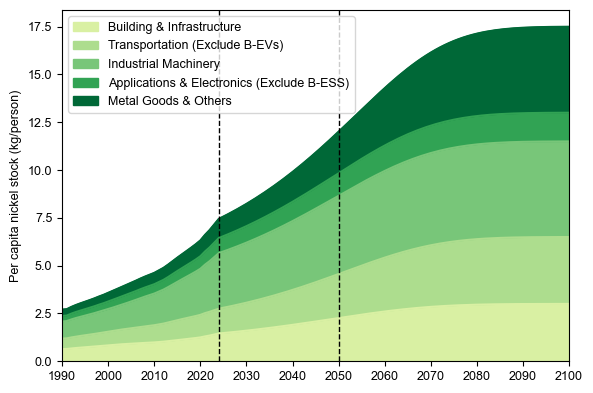

In [5]:
def plot_per_capita(df):
    year_min = 1990
    
    fig, ax = plt.subplots(1,1, figsize=(6, 4))
    df.plot.area(ax=ax, y=Old_Sectors, color=Old_Sector_Colors, legend=True)
            
    ax.set_xlim(year_min, 2100)
    ax.set_xticks(np.arange(year_min, 2101, 10))
    ax.set_ylabel('Per capita nickel stock (kg/person)')
    ax.set_xlabel('')
    ax.axvline(x=2024, color="black", linestyle="--", lw=1)
    ax.axvline(x=2050, color="black", linestyle="--", lw=1)
    #plt.legend(frameon=False)
    
    plt.savefig(file_path + 'Sector_Cu_Ni_Co/Nickel_per_capita_stock.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.tight_layout()
    plt.show()
    
    
plot_per_capita(df_per_capita)

- lifetime distribution

In [6]:
df_per_capita = df_per_capita.loc[:2050:]
df_per_capita.tail(2)

,Building & Infrastructure,Transportation (Exclude B-EVs),Industrial Machinery,Applications & Electronics (Exclude B-ESS),Metal Goods & Others,Total
Sector,,,,,,
2049,2.224502,2.250602,4.045783,1.158639,2.101553,11.781080
2050,2.260995,2.301909,4.094573,1.175339,2.173898,12.006714


In [7]:
df_lifetime = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='lifetime', index_col=[0,1], header=2)
df_lifetime = df_lifetime.T
df_lifetime.tail(2)

Scenario                  Constant                 \
Sector   Building & Infrastructure Transportation   
2049                          30.0           25.0   
2050                          30.0           25.0   

Scenario                                                            \
Sector   Transportation (Exclude B-EVs) B-EVs Industrial Machinery   
2049                               25.0   NaN                 50.0   
2050                               25.0   NaN                 50.0   

Scenario                             \
Sector   Applications & Electronics   
2049                           14.0   
2050                           14.0   

Scenario                                                   \
Sector   Applications & Electronics (Exclude B-ESS) B-ESS   
2049                                           14.0   NaN   
2050                                           14.0   NaN   

Scenario                                         Longer                 \
Sector   Metal Goods & Others Building & Infrastructure Transportation   
2049                     15.0                 38.472960      32.060800   
2050                     15.0                 38.857689      32.381408   

Scenario                                                            \
Sector   Transportation (Exclude B-EVs) B-EVs Industrial Machinery   
2049                          32.060800   NaN            64.121600   
2050                          32.381408   NaN            64.762816   

Scenario                             \
Sector   Applications & Electronics   
2049                      17.954048   
2050                      18.133588   

Scenario                                                                        
Sector   Applications & Electronics (Exclude B-ESS) B-ESS Metal Goods & Others  
2049                                      17.954048   NaN            19.236480  
2050                                      18.133588   NaN            19.428845

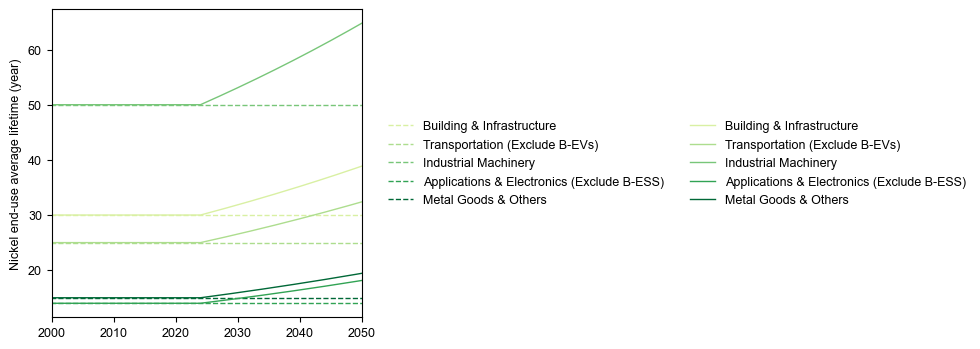

In [8]:
def plot_lifetime(df):
    year_min = 2000
    
    fig, ax = plt.subplots(1,1, figsize=(4,4))
    
    for sector in Old_Sectors:
        ax.plot(df.index, df['Constant',sector], label=sector, color=sector_color_dict[sector], lw=1, linestyle='--')
        
    for sector in Old_Sectors:
        ax.plot(df.index, df['Longer',sector], label=sector, color=sector_color_dict[sector], lw=1)
        
    ax.set_ylabel('Nickel end-use average lifetime (year)')
    ax.set_xlim(year_min,2050)
    ax.set_xticks(np.arange(year_min,2051,10))
    ax.legend(frameon=False, ncol=2, loc='center left', bbox_to_anchor=(1.05,0.5))
    
    #plt.savefig(file_path + r'Sector_Cu_Ni_Co\Nickel_Enduse_Lifetime.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()
    
    
plot_lifetime(df_lifetime)

- Traditional use
- stock, inflow, outflow
- million persons * kg/person = kt

In [9]:
def cal_traditional_stock_flow(df_pop, df_capita, df_lt):
    
    df_stock = pd.DataFrame(index=df_capita.index, 
                            columns=pd.MultiIndex.from_product([Lifetime_Scenarios,Old_Sectors],names=['Lifetime','Sector']))
    df_inflow = df_stock.copy()
    df_outflow = df_inflow.copy()
    
    for lt in Lifetime_Scenarios:
        for s in Old_Sectors:
            df_stock[(lt,s)] = df_pop['World'] * df_capita[s]
            ## stock-driven
            DSM = DynamicStockModel(t = list(df_stock.index), 
                                    s = list(df_stock[(lt,s)]), 
                                    lt = {'Type': 'Normal',
                                          'Mean': list(df_lt[(lt,s)]),    
                                          'StdDev': list(0.3 * df_lt[(lt,s)])})
            DSM.compute_stock_driven_model()
            DSM.compute_outflow_total()
            ## fill in
            df_inflow[(lt,s)] = DSM.i
            df_outflow[(lt,s)] = DSM.o
                
    ## 第二轮
    df_inflow_2 = df_inflow.mask(df_inflow<0, 0)
    df_stock_2 = pd.DataFrame(index=df_capita.index, 
                              columns=pd.MultiIndex.from_product([Lifetime_Scenarios,Old_Sectors],names=['Lifetime','Sector']))
    df_outflow_2 = df_stock_2.copy()
    
    for lt in Lifetime_Scenarios:
        for s in Old_Sectors:
            ## inflow-driven
            DSM = DynamicStockModel(t = list(df_inflow_2.index), 
                                    i = list(df_inflow_2[(lt,s)]), 
                                    lt = {'Type': 'Normal',
                                          'Mean': list(df_lt[(lt,s)]),    
                                          'StdDev': list(0.3 * df_lt[(lt,s)])})
            DSM.compute_s_c_inflow_driven()
            DSM.compute_stock_total()
            DSM.compute_o_c_from_s_c()
            DSM.compute_outflow_total()
            ## fill in 
            df_stock_2[(lt,s)] = DSM.s
            df_outflow_2[(lt,s)] = DSM.o
                
                
    return df_stock_2, df_inflow_2, df_outflow_2


df_traditional_stock, df_traditional_inflow, df_traditional_outflow = cal_traditional_stock_flow(df_pop, df_per_capita, df_lifetime)
df_traditional_inflow.tail(2)

Lifetime                  Constant                                 \
Sector   Building & Infrastructure Transportation (Exclude B-EVs)   
Sector                                                              
2049                    896.122979                    1107.113630   
2050                    911.254961                    1131.030942   

Lifetime                                                                  \
Sector   Industrial Machinery Applications & Electronics (Exclude B-ESS)   
Sector                                                                     
2049               995.646879                                 825.986729   
2050              1010.920424                                 841.377391   

Lifetime                                         Longer  \
Sector   Metal Goods & Others Building & Infrastructure   
Sector                                                    
2049              1626.748474                868.497251   
2050              1690.842975                878.312385   

Lifetime                                                      \
Sector   Transportation (Exclude B-EVs) Industrial Machinery   
Sector                                                         
2049                        1050.989459            990.31210   
2050                        1065.464498           1004.50762   

Lifetime                                                                  
Sector   Applications & Electronics (Exclude B-ESS) Metal Goods & Others  
Sector                                                                    
2049                                     720.975036          1462.726610  
2050                                     730.148879          1512.541069

In [10]:
df_traditional_stock.tail(2)

Lifetime                  Constant                                 \
Sector   Building & Infrastructure Transportation (Exclude B-EVs)   
Sector                                                              
2049                  20283.594110                   20521.584651   
2050                  20692.874594                   21067.321351   

Lifetime                                                                  \
Sector   Industrial Machinery Applications & Electronics (Exclude B-ESS)   
Sector                                                                     
2049             36890.514331                               10564.771415   
2050             37473.989651                               10756.835336   

Lifetime                                         Longer  \
Sector   Metal Goods & Others Building & Infrastructure   
Sector                                                    
2049             19162.516723              20283.594110   
2050             19895.753286              20692.874594   

Lifetime                                                      \
Sector   Transportation (Exclude B-EVs) Industrial Machinery   
Sector                                                         
2049                       20521.584651         36890.514331   
2050                       21067.321351         37473.989651   

Lifetime                                                                  
Sector   Applications & Electronics (Exclude B-ESS) Metal Goods & Others  
Sector                                                                    
2049                                   10564.771415         19162.516723  
2050                                   10756.835336         19895.753286

## Demand: Bottom-up (Emerging use)

In [11]:
def full_fill(df):
    df_temp = pd.DataFrame(index=np.arange(1900,df.index.min()), columns=df.columns)
    df_temp.fillna(value=0, inplace=True)
    df_output  = pd.concat([df_temp, df])
    
    return df_output

- ESS (kt)

In [12]:
df_ESS_stock = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_stock', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_stock = df_ESS_stock.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime','Region']).sum()
df_ESS_stock = df_ESS_stock.T
df_ESS_stock = df_ESS_stock['Nickel']
df_ESS_stock = full_fill(df_ESS_stock)
df_ESS_stock.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_29844\1312265970.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


ESS Scenario             APS                                                  \
Battery Scenario    Baseline                                                   
Lifetime            Constant                                                   
Region                 China          EU      Japan          RoW         USA   
2049              826.516815  297.024353  26.022883  1294.299589  490.184356   
2050              835.986566  311.383346  27.116069  1360.288820  495.564852   

ESS Scenario                                                                  \
Battery Scenario                                                               
Lifetime              Longer                                                   
Region                 China          EU      Japan          RoW         USA   
2049              826.516815  297.024353  26.022883  1294.299589  490.184356   
2050              835.986566  311.383346  27.116069  1360.288820  495.564852   

ESS Scenario      ...       STEPS                                   \
Battery Scenario  ...   Optimized                                    
Lifetime          ...    Constant                                    
Region            ...       China         EU     Japan         RoW   
2049              ...  289.910815  71.372531  3.591073  202.674633   
2050              ...  290.843539  73.957731  3.516581  208.360512   

ESS Scenario                                                               \
Battery Scenario                                                            
Lifetime                          Longer                                    
Region                   USA       China         EU     Japan         RoW   
2049              159.894744  310.503753  75.287065  3.916416  214.025871   
2050              159.749502  310.833732  77.876312  3.816517  219.865197   

ESS Scenario                  
Battery Scenario              
Lifetime                      
Region                   USA  
2049              171.722505  
2050              171.170806  

[2 rows x 180 columns]

In [13]:
df_ESS_inflow = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_inflow', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_inflow = df_ESS_inflow.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime','Region']).sum()
df_ESS_inflow = df_ESS_inflow.T
df_ESS_inflow = df_ESS_inflow['Nickel']
df_ESS_inflow = full_fill(df_ESS_inflow)
df_ESS_inflow.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_29844\1312265970.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


ESS Scenario            APS                                              \
Battery Scenario   Baseline                                               
Lifetime           Constant                                               
Region                China         EU     Japan         RoW        USA   
2049              81.638950  35.609416  2.991268  156.210153  49.489640   
2050              83.983283  36.825162  3.066041  162.438612  50.197073   

ESS Scenario                                                             ...  \
Battery Scenario                                                         ...   
Lifetime             Longer                                              ...   
Region                China         EU     Japan         RoW        USA  ...   
2049              49.655976  25.679950  2.308494  111.411009  31.291806  ...   
2050              50.587218  26.099191  2.303277  114.006997  31.423167  ...   

ESS Scenario          STEPS                                            \
Battery Scenario  Optimized                                             
Lifetime           Constant                                             
Region                China        EU     Japan        RoW        USA   
2049              28.207039  8.113251  0.300572  22.223388  15.353986   
2050              28.390185  8.264583  0.296418  22.648927  15.375360   

ESS Scenario                                                           
Battery Scenario                                                       
Lifetime             Longer                                            
Region                China        EU     Japan        RoW        USA  
2049              18.796714  6.024202  0.199192  15.721353  10.106063  
2050              18.685307  6.020924  0.193416  15.777416  10.021350  

[2 rows x 180 columns]

In [14]:
df_ESS_outflow = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_outflow', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_outflow = df_ESS_outflow.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime','Region']).sum()
df_ESS_outflow = df_ESS_outflow.T
df_ESS_outflow = df_ESS_outflow['Nickel']
df_ESS_outflow = full_fill(df_ESS_outflow)
df_ESS_outflow.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_29844\1312265970.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


ESS Scenario            APS                                             \
Battery Scenario   Baseline                                              
Lifetime           Constant                                              
Region                China         EU     Japan        RoW        USA   
2049              72.169199  21.250423  1.898082  90.220923  44.109144   
2050              74.513532  22.466170  1.972854  96.449381  44.816577   

ESS Scenario                                                            ...  \
Battery Scenario                                                        ...   
Lifetime             Longer                                             ...   
Region                China         EU     Japan        RoW        USA  ...   
2049              40.186225  11.320957  1.215308  45.421778  25.911310  ...   
2050              41.117468  11.740199  1.210090  48.017767  26.042671  ...   

ESS Scenario          STEPS                                            \
Battery Scenario  Optimized                                             
Lifetime           Constant                                             
Region                China        EU     Japan        RoW        USA   
2049              27.503513  5.482025  0.383826  16.432597  15.669673   
2050              27.457460  5.679383  0.370909  16.963048  15.520603   

ESS Scenario                                                          
Battery Scenario                                                      
Lifetime             Longer                                           
Region                China        EU     Japan       RoW        USA  
2049              18.781302  3.397252  0.308117  9.819446  10.880268  
2050              18.355328  3.431677  0.293315  9.938090  10.573050  

[2 rows x 180 columns]

- vehicle: battery mateiral (kt)

In [15]:
df_EV_stock = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_stock', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_stock = df_EV_stock.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime','Region']).sum()
df_EV_stock = df_EV_stock.T
df_EV_stock = df_EV_stock['Nickel']
df_EV_stock = full_fill(df_EV_stock)
df_EV_stock.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_29844\1312265970.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


Powertrain Scenario           APS                                           \
Segment Scenario         Baseline                                            
Battery Size               Larger                                            
Battery Scenario         Baseline                                            
Lifetime                 Constant                                            
Region                      China            EU        Japan           RoW   
2049                  9573.164281   9890.426603  1065.333765  24818.947584   
2050                 10024.192334  10309.139842  1121.123618  27062.859691   

Powertrain Scenario                                                      \
Segment Scenario                                                          
Battery Size                                                              
Battery Scenario                                                          
Lifetime                               Longer                             
Region                       USA        China           EU        Japan   
2049                 6228.274334  9206.252954  9460.005677  1005.552086   
2050                 6695.753520  9616.457778  9881.805767  1056.418553   

Powertrain Scenario                             ...        STEPS               \
Segment Scenario                                ...     Baseline                
Battery Size                                    ...       Larger                
Battery Scenario                                ...    Optimized                
Lifetime                                        ...     Constant                
Region                        RoW          USA  ...        China           EU   
2049                 23433.562083  5937.103626  ...  2004.621027  1447.640139   
2050                 25506.009119  6369.767314  ...  1995.365364  1506.749992   

Powertrain Scenario                                                    \
Segment Scenario                                                        
Battery Size                                                            
Battery Scenario                                                        
Lifetime                                                       Longer   
Region                    Japan          RoW         USA        China   
2049                 152.353270  3064.693865  733.038482  2120.759928   
2050                 158.943087  3266.678499  758.438117  2107.657002   

Powertrain Scenario                                                    
Segment Scenario                                                       
Battery Size                                                           
Battery Scenario                                                       
Lifetime                                                               
Region                        EU       Japan          RoW         USA  
2049                 1438.795262  147.525581  3016.501958  746.223904  
2050                 1492.757619  153.520937  3207.955169  769.885019  

[2 rows x 180 columns]

In [16]:
df_EV_inflow = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_inflow', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_inflow = df_EV_inflow.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime','Region']).sum()
df_EV_inflow = df_EV_inflow.T
df_EV_inflow = df_EV_inflow['Nickel']
df_EV_inflow = full_fill(df_EV_inflow)
df_EV_inflow.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_29844\1312265970.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


Powertrain Scenario          APS                                        \
Segment Scenario        Baseline                                         
Battery Size              Larger                                         
Battery Scenario        Baseline                                         
Lifetime                Constant                                         
Region                     China           EU       Japan          RoW   
2049                 1344.402080  1362.750383  152.404994  4022.315144   
2050                 1400.864108  1398.370815  159.279766  4336.721487   

Powertrain Scenario                                                   \
Segment Scenario                                                       
Battery Size                                                           
Battery Scenario                                                       
Lifetime                              Longer                           
Region                       USA       China          EU       Japan   
2049                  961.636844  878.655399  881.617384   98.484654   
2050                 1025.158415  900.354823  893.305037  101.356729   

Powertrain Scenario                           ...       STEPS              \
Segment Scenario                              ...    Baseline               
Battery Size                                  ...      Larger               
Battery Scenario                              ...   Optimized               
Lifetime                                      ...    Constant               
Region                       RoW         USA  ...       China          EU   
2049                 2804.887367  657.857784  ...  231.685494  199.337219   
2050                 2984.268510  692.171603  ...  230.091704  206.153820   

Powertrain Scenario                                                 \
Segment Scenario                                                     
Battery Size                                                         
Battery Scenario                                                     
Lifetime                                                    Longer   
Region                   Japan         RoW         USA       China   
2049                 21.133579  459.749865   98.770930  147.033528   
2050                 21.830383  484.684823  101.748591  143.442601   

Powertrain Scenario                                                
Segment Scenario                                                   
Battery Size                                                       
Battery Scenario                                                   
Lifetime                                                           
Region                       EU      Japan         RoW        USA  
2049                 132.393963  13.782922  319.651721  66.402736  
2050                 134.954785  14.005902  332.525256  67.470151  

[2 rows x 180 columns]

In [17]:
df_EV_outflow = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_outflow', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_outflow = df_EV_outflow.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime','Region']).sum()
df_EV_outflow = df_EV_outflow.T
df_EV_outflow = df_EV_outflow['Nickel']
df_EV_outflow = full_fill(df_EV_outflow)
df_EV_outflow.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_29844\1312265970.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


Powertrain Scenario         APS                                      \
Segment Scenario       Baseline                                       
Battery Size             Larger                                       
Battery Scenario       Baseline                                       
Lifetime               Constant                                       
Region                    China          EU       Japan         RoW   
2049                 900.335087  917.873982   97.177802  1880.14642   
2050                 949.836055  979.657577  103.489912  2092.80938   

Powertrain Scenario                                                 \
Segment Scenario                                                     
Battery Size                                                         
Battery Scenario                                                     
Lifetime                             Longer                          
Region                      USA       China          EU      Japan   
2049                 511.375072  476.518763  444.798154  48.228895   
2050                 557.679229  490.149998  471.504947  50.490262   

Powertrain Scenario                          ...       STEPS              \
Segment Scenario                             ...    Baseline               
Battery Size                                 ...      Larger               
Battery Scenario                             ...   Optimized               
Lifetime                                     ...    Constant               
Region                      RoW         USA  ...       China          EU   
2049                 837.359641  243.462122  ...  240.809897  140.768460   
2050                 911.821474  259.507915  ...  239.347367  147.043967   

Powertrain Scenario                                                           \
Segment Scenario                                                               
Battery Size                                                                   
Battery Scenario                                                               
Lifetime                                                   Longer              
Region                   Japan         RoW        USA       China         EU   
2049                 14.476391  262.003710  73.741977  161.467444  80.081736   
2050                 15.240566  282.700189  76.348956  156.545527  80.992429   

Powertrain Scenario                                   
Segment Scenario                                      
Battery Size                                          
Battery Scenario                                      
Lifetime                                              
Region                  Japan         RoW        USA  
2049                 7.835286  134.693602  43.664141  
2050                 8.010546  141.072045  43.809036  

[2 rows x 180 columns]

## Nickel cycle
- dissipation loss rate

In [18]:
df_dissipation_rate = pd.read_excel(file_path + r'Sector_Cu_Ni_Co\5Regions\by-Nickel_compile_data_world.xlsx', sheet_name='dissipation', index_col=[0], header=2)
df_dissipation_rate.fillna(0, inplace=True)
df_dissipation_rate

,Dissipation rate
Sector,
Building & Infrastructure,0.0001
Transportation,0.0001
Transportation (Exclude B-EVs),0.0001
B-EVs,0.0001
Industrial Machinery,0.0000
Applications & Electronics,0.0000
Applications & Electronics (Exclude B-ESS),0.0000
B-ESS,0.0000
Metal Goods & Others,0.0050


- loss rate

In [19]:
df_parameters = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='parameters', index_col=[0,1], header=2)
df_parameters = df_parameters.T
df_parameters.tail(2)

Scenario          Constant                                        \
Loss rate mining loss rate smelting loss rate refining loss rate   
2049              0.143398           0.056408           0.043997   
2050              0.143398           0.056408           0.043997   

Scenario                                                        \
Loss rate primary processing loss rate manufacturing loss rate   
2049                              0.21                    0.14   
2050                              0.21                    0.14   

Scenario                                                       \
Loss rate new scrap collection rate old scrap collection rate   
2049                           0.86                      0.63   
2050                           0.86                      0.63   

Scenario                              Efficient                     \
Loss rate recycling efficiency mining loss rate smelting loss rate   
2049                       1.0         0.039777           0.015647   
2050                       1.0         0.037788           0.014865   

Scenario                                                   \
Loss rate refining loss rate primary processing loss rate   
2049                0.012204                     0.058252   
2050                0.011594                     0.055339   

Scenario                                                     \
Loss rate manufacturing loss rate new scrap collection rate   
2049                     0.038835                  0.949975   
2050                     0.036893                  0.949975   

Scenario                                                  
Loss rate old scrap collection rate recycling efficiency  
2049                       0.807932                  1.0  
2050                       0.816011                  1.0

- scrap ratio

In [20]:
df_scrap_ratio = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='scrap ratio', index_col=[0], header=2)
df_scrap_ratio

,Value
Indicator,
Clean scrap ratio of new scrap,1.000000
Clean scrap ratio of old scrap,0.981333


- statistics (from t to kt)

In [21]:
df_world_statistics = pd.read_excel(file_path + r'Sector_Cu_Ni_Co\World\by-Nickel_compile_data_world.xlsx', sheet_name='Statistics', index_col=[0], header=2)
df_world_statistics = df_world_statistics/ 1000 ## from ton to kt
df_world_statistics.loc[2020:2024,:]

,mine_production,refining_production
Year,,
2020,2429.926,2530.0
2021,2810.000,2650.0
2022,3250.000,2990.0
2023,3750.000,3390.0
2024,3710.000,NaN


In [22]:
def rename_sector(s):
    if s in ['B-ESS','B-EVs','Building & Infrastructure','Metal Goods & Others']:
        return s
    elif s == 'Transportation (Exclude B-EVs)':
        return 'Transportation'
    elif s == 'Industrial Machinery':
        return 'Industrial Equipment'
    elif s == 'Applications & Electronics (Exclude B-ESS)':
        return 'B-CEs'
    
    
def reconstruct_sector(df):
    df = df.copy()
    
    df = df.T
    df['Sector'] = df.index
    df.Sector = df.Sector.apply(rename_sector)
    df = df.groupby(['Sector']).sum().T
    
    return df

In [23]:
def extract_all_sectors(df_traditional, df_ess, df_battery):
    
    df_output = pd.DataFrame(index=df_pop.index, columns=New_Sectors)
    
    ## fill traditional use
    for s in Old_Sectors:
        ## Lifetime, Sector
        df_output[s] = df_traditional['Constant',s]
        
    ## fill ESS
    ## ESS Scenario, Battery Scenario, Lifetime, Region
    df_output['B-ESS'] = df_ess['APS','Baseline','Constant'].sum(axis=1)
        
    ## fill vehicle (battery + component)
    ## Powertrain Scenario, Segment Scenario, Battery Size, Battery Scenario, Lifetime
    df_output['B-EVs'] = df_battery['APS','Baseline','Larger','Baseline','Constant'].sum(axis=1)
        
    return df_output


df_sectors_inflow = extract_all_sectors(df_traditional_inflow, df_ESS_inflow, df_EV_inflow)
df_sectors_inflow.tail(2)

,Building & Infrastructure,Transportation (Exclude B-EVs),Industrial Machinery,Applications & Electronics (Exclude B-ESS),Metal Goods & Others,B-ESS,B-EVs
Region,,,,,,,
2049,896.122979,1107.113630,995.646879,825.986729,1626.748474,325.939427,7843.509446
2050,911.254961,1131.030942,1010.920424,841.377391,1690.842975,336.510170,8320.394591


In [24]:
df_sectors_inflow_2 = reconstruct_sector(df_sectors_inflow)
df_sectors_inflow_2.tail(2)

Sector,B-CEs,B-ESS,B-EVs,Building & Infrastructure,Industrial Equipment,Metal Goods & Others,Transportation
Region,,,,,,,
2049,825.986729,325.939427,7843.509446,896.122979,995.646879,1626.748474,1107.113630
2050,841.377391,336.510170,8320.394591,911.254961,1010.920424,1690.842975,1131.030942


In [25]:
df_sectors_outflow = extract_all_sectors(df_traditional_outflow, df_ESS_outflow, df_EV_outflow)
df_sectors_outflow_2 = reconstruct_sector(df_sectors_outflow)
df_sectors_outflow.tail(2)

,Building & Infrastructure,Transportation (Exclude B-EVs),Industrial Machinery,Applications & Electronics (Exclude B-ESS),Metal Goods & Others,B-ESS,B-EVs
Region,,,,,,,
2049,489.085656,570.325727,411.344167,634.352084,920.486284,229.647771,4306.908363
2050,501.974477,585.294243,427.445104,649.313470,957.606411,240.218513,4683.472153


In [26]:
df_sectors_stock = extract_all_sectors(df_traditional_stock, df_ESS_stock, df_EV_stock)
df_sectors_stock_2 = reconstruct_sector(df_sectors_stock)
df_sectors_stock.tail(2)

,Building & Infrastructure,Transportation (Exclude B-EVs),Industrial Machinery,Applications & Electronics (Exclude B-ESS),Metal Goods & Others,B-ESS,B-EVs
Region,,,,,,,
2049,20283.594110,20521.584651,36890.514331,10564.771415,19162.516723,2934.047996,51576.146567
2050,20692.874594,21067.321351,37473.989651,10756.835336,19895.753286,3030.339653,55213.069006


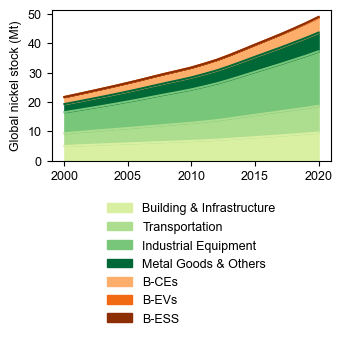

In [27]:
def plot_area(df, name):
    
    df = df / 1e3 # from kt to Mt
    year_min=2000
    year_max=2020
    df = df.loc[year_min:year_max,]
    
    fig, ax = plt.subplots(1,1, figsize=(3.5, 2))
    
    df_s = df.T.groupby(['Sector']).sum().T
    df_s.plot.area(ax=ax, y=Agg_Sectors, color=Agg_Sector_Colors, legend=False)

    ax.set_ylabel('Global nickel '+ name +' (Mt)')
    #ax.set_xlim(year_min,year_max)
    #ax.set_ylim(0,40)
    ax.set_xlabel('')
    #ax.set_xticks(np.arange(year_min,year_max+1,5))
        
    plt.tight_layout()
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), frameon=False)
    
    #plt.savefig(file_path + r'Sector_Cu_Ni_Co\His_Nickel.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()

plot_area(df_sectors_stock_2, 'stock')

In [28]:
df_sectors_inflow.tail(2)

,Building & Infrastructure,Transportation (Exclude B-EVs),Industrial Machinery,Applications & Electronics (Exclude B-ESS),Metal Goods & Others,B-ESS,B-EVs
Region,,,,,,,
2049,896.122979,1107.113630,995.646879,825.986729,1626.748474,325.939427,7843.509446
2050,911.254961,1131.030942,1010.920424,841.377391,1690.842975,336.510170,8320.394591


In [29]:
def agg_world_results(df_inflow, df_stock, df_outflow, df_dissipation, df_para, df_scrap_r, df_stat):
    
    df_apc = pd.DataFrame(index=df_inflow.index, columns=df_inflow.columns)
    df_dissip = df_apc.copy()
    for sector in df_apc.columns:
        df_apc[sector] = df_inflow[sector] / (1-df_dissipation.at[sector, 'Dissipation rate'])
        df_dissip[sector] = df_apc[sector] * df_dissipation.at[sector, 'Dissipation rate']
    ################# 起算点
    df_world = pd.DataFrame(index=df_apc.index)
    df_world['Inflow'] = df_inflow.sum(axis=1)
    df_world['P4_P5'] = df_apc.sum(axis=1)
    df_world['P5_E0'] = df_dissip.sum(axis=1)
    
    ################# 往后算
    ## Outflow
    df_world['Stock'] = df_stock.sum(axis=1)
    df_world['Outflow'] = df_outflow.sum(axis=1)
    df_world['P5_P6'] = df_outflow.sum(axis=1)
    
    ## Secondary supply
    df_old_sec = pd.DataFrame(index=df_outflow.index, columns=df_outflow.columns)
    for sector in New_Sectors:
        df_old_sec[sector] = df_outflow[sector] *  df_para['Constant','old scrap collection rate']
    df_world['P6_P3'] = df_old_sec.sum(axis=1)
    df_world['P6_E0'] = df_world['P5_P6'] - df_world['P6_P3']
    
    ################ 往前算
    df_world['Total_manufacturing_input'] = df_world['P4_P5'] / (1-df_para['Constant','manufacturing loss rate'])
    df_world['P4_P3'] = df_world['Total_manufacturing_input'] * df_para['Constant','manufacturing loss rate'] * df_para['Constant','new scrap collection rate']
    df_world['P4_E0'] = df_world['Total_manufacturing_input'] - df_world['P4_P5'] - df_world['P4_P3'] 

    df_world['P3_P4'] = df_world['P4_P3']*df_scrap_r.at['Clean scrap ratio of new scrap','Value'] + df_world['P6_P3']*df_scrap_r.at['Clean scrap ratio of old scrap','Value']
    df_world['P2_P4'] = df_world['Total_manufacturing_input'] - df_world['P3_P4']
    
    df_world['P3_P2'] = (df_world['P4_P3'] * (1-df_scrap_r.at['Clean scrap ratio of new scrap','Value']) + df_world['P6_P3'] * (1-df_scrap_r.at['Clean scrap ratio of old scrap','Value'])) * (df_para['Constant','recycling efficiency'])
    df_world['P3_E0'] = (df_world['P4_P3'] * (1-df_scrap_r.at['Clean scrap ratio of new scrap','Value']) + df_world['P6_P3'] * (1-df_scrap_r.at['Clean scrap ratio of old scrap','Value'])) * (1-df_para['Constant','recycling efficiency'])
    
    df_world['P1_P2'] = (df_world['P2_P4']-df_world['P3_P2'])/ (1-df_para['Constant','refining loss rate']) / (1-df_para['Constant','smelting loss rate'])
    df_world['P2_E0'] = df_world['P1_P2'] + df_world['P3_P2'] - df_world['P2_P4']
    
    df_world['L0_P1'] = df_world['P1_P2'] / (1-df_para['Constant','mining loss rate'])
    df_world['P1_E0'] = df_world['L0_P1'] - df_world['P1_P2']

    ################ 与统计数据进行比较
    df_world['Mining'] = df_stat['mine_production']
    df_world['Refining'] = df_stat['refining_production']
    df_world = df_world[['L0_P1','P1_P2','Mining','P2_P4','Total_manufacturing_input','Refining','P4_P5','Inflow','Stock','Outflow','P5_P6',
                         'P6_P3','P4_P3','P3_P4','P3_P2',
                         'P1_E0','P2_E0','P3_E0','P4_E0','P5_E0','P6_E0']]
    return df_world


df_world_flow = agg_world_results(df_sectors_inflow, df_sectors_stock, df_sectors_outflow, df_dissipation_rate, df_parameters, df_scrap_ratio, df_world_statistics)

df_world_flow['EoL-RR'] = df_world_flow['P6_P3'] / df_world_flow['Outflow'] 
df_world_flow['EoL-RIR'] = df_world_flow['P6_P3'] / df_world_flow['Inflow']
df_world_flow['Mining_Variance'] = (df_world_flow['P1_P2'] - df_world_flow['Mining']) / df_world_flow['Mining'] *100
df_world_flow['Refining_Variance'] = (df_world_flow['P2_P4'] - df_world_flow['Refining']) / df_world_flow['Refining'] *100
#df_world_flow.to_excel('test_Nickel.xlsx')

In [30]:
pd.set_option('display.max_columns', None)
df_world_flow.loc[2020:2030,:]

,L0_P1,P1_P2,Mining,P2_P4,Total_manufacturing_input,Refining,P4_P5,Inflow,Stock,Outflow,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2,P1_E0,P2_E0,P3_E0,P4_E0,P5_E0,P6_E0,EoL-RR,EoL-RIR,Mining_Variance,Refining_Variance
Region,,,,,,,,,,,,,,,,,,,,,,,,,
2020,3322.403540,2845.976319,2429.926,2580.062846,3696.660415,2530.0,3179.127957,3176.140713,48994.954300,1086.179566,1086.179566,684.293126,445.077914,1116.597569,12.773472,476.427221,278.686944,0.0,72.454544,2.987244,401.886439,0.63,0.215448,17.121934,1.978769
2021,3642.267704,3119.972486,2810.000,2827.737538,4008.663881,2650.0,3447.450937,3444.211566,51309.696385,1129.469481,1129.469481,711.565773,482.643131,1180.926343,13.282561,522.295218,305.517510,0.0,78.569812,3.239371,417.903708,0.63,0.206598,11.031049,6.707077
2022,4027.320931,3449.809712,3250.000,3125.835677,4381.012357,2990.0,3767.670627,3764.130364,53896.771249,1177.055500,1177.055500,741.544965,527.473888,1255.176680,13.842173,577.511219,337.816207,0.0,85.867842,3.540263,435.510535,0.63,0.197003,6.147991,4.542999
2023,4574.274325,3918.330886,3750.000,3549.101214,4899.475358,3390.0,4213.548808,4209.589579,56876.292713,1230.068115,1230.068115,774.942912,589.896833,1350.374145,14.465601,655.943439,383.695273,0.0,96.029717,3.959229,455.125203,0.63,0.184090,4.488824,4.693251
2024,4466.457927,3825.975182,3710.000,3466.486342,4847.214288,NaN,4168.604287,4164.687290,59751.637117,1289.342885,1289.342885,812.286018,583.604600,1380.727946,15.162672,640.482745,374.651512,0.0,95.005400,3.916998,477.056868,0.63,0.195041,3.126016,NaN
2025,3282.849472,2812.094239,NaN,2552.666553,3854.854107,NaN,3315.174532,3311.921865,61707.996224,1355.562759,1355.562759,854.004538,464.124435,1302.187554,15.941418,470.755233,275.369104,0.0,75.555141,3.252667,501.558221,0.63,0.257858,NaN,NaN
2026,3451.227522,2956.327153,NaN,2683.653943,4056.259839,NaN,3488.383462,3484.998881,63762.754079,1430.241026,1430.241026,901.051846,488.373685,1372.605896,16.819634,494.900369,289.492845,0.0,79.502693,3.384581,529.189180,0.63,0.258552,NaN,NaN
2027,3700.752927,3170.071024,NaN,2877.452005,4335.435823,NaN,3728.474808,3724.912924,65973.696142,1513.970861,1513.970861,953.801643,521.986473,1457.983818,17.804297,530.681903,310.423316,0.0,84.974542,3.561884,560.169219,0.63,0.256060,NaN,NaN
2028,3967.199850,3398.309895,NaN,3084.445341,4636.765591,NaN,3987.618408,3983.868101,68349.687573,1607.876670,1607.876670,1012.962302,558.266577,1552.320250,18.908630,568.889955,332.773184,0.0,90.880606,3.750307,594.914368,0.63,0.254266,NaN,NaN


In [31]:
df_world_flow.loc[2000:2024,:]

,L0_P1,P1_P2,Mining,P2_P4,Total_manufacturing_input,Refining,P4_P5,Inflow,Stock,Outflow,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2,P1_E0,P2_E0,P3_E0,P4_E0,P5_E0,P6_E0,EoL-RR,EoL-RIR,Mining_Variance,Refining_Variance
Region,,,,,,,,,,,,,,,,,,,,,,,,,
2000,1472.992897,1250.008334,1274.457000,1117.875503,1616.490597,1118.420,1390.181913,1388.886480,21733.682548,491.701646,491.701646,309.772037,194.625468,498.615094,5.782411,222.984562,137.915243,0.0,31.683216,1.295433,181.929609,0.63,0.223036,-1.918359,-0.048684
2001,1531.463932,1300.239240,1335.368000,1163.597380,1682.108567,1187.901,1446.613367,1445.263093,22667.841028,511.104613,511.104613,321.995906,202.525871,518.511187,6.010590,231.224693,142.652451,0.0,32.969328,1.350275,189.108707,0.63,0.222794,-2.630643,-2.045930
2002,1550.672578,1317.166709,1350.787000,1179.731917,1715.316141,1200.897,1475.171882,1473.792650,23609.380570,532.253108,532.253108,335.319458,206.524063,535.584225,6.259297,233.505869,143.694088,0.0,33.620196,1.379232,196.933650,0.63,0.227521,-2.488941,-1.762440
2003,1583.339542,1345.546602,1369.076000,1206.118941,1761.446227,1218.844,1514.843755,1513.425068,24567.601899,555.203739,555.203739,349.778356,212.078126,555.327285,6.529196,237.792941,145.956856,0.0,34.524346,1.418686,205.425383,0.63,0.231117,-1.718633,-1.044027
2004,1614.410246,1372.595411,1373.793000,1231.374283,1807.513791,1271.095,1554.461861,1553.003647,25540.709634,579.895911,579.895911,365.334424,217.624660,576.139509,6.819576,241.814836,148.040704,0.0,35.427270,1.458214,214.561487,0.63,0.235244,-0.087174,-3.124921
2005,1675.252403,1424.993038,1460.981000,1279.312495,1880.481600,1305.533,1617.214176,1615.694573,26550.233270,606.170937,606.170937,381.887690,226.409985,601.169105,7.128570,250.259365,152.809112,0.0,36.857439,1.519603,224.283247,0.63,0.236361,-2.463274,-2.008414
2006,1727.778257,1470.361956,1560.147000,1321.051958,1947.324903,1354.320,1674.699417,1673.125798,27589.600290,633.758778,633.758778,399.268030,234.457918,626.272945,7.453003,257.416301,156.763002,0.0,38.167568,1.573619,234.490748,0.63,0.238636,-5.754909,-2.456439
2007,1808.321558,1539.627208,1646.058589,1384.223184,2039.242967,1437.253,1753.748951,1752.101054,28679.345415,662.355929,662.355929,417.284235,245.524853,655.019783,7.789306,268.694350,163.193330,0.0,39.969162,1.647897,245.071694,0.63,0.238162,-6.465832,-3.689665
2008,1772.900462,1510.176958,1580.806247,1359.174909,2031.326835,1401.338,1746.941078,1745.299578,29733.036273,691.608720,691.608720,435.713494,244.571751,672.151926,8.133319,262.723504,159.135368,0.0,39.814006,1.641500,255.895227,0.63,0.249650,-4.467928,-3.008774


In [32]:
df_world_flow.loc[2000:2024,:].sum() / 1000

L0_P1                         62.615595
P1_P2                         53.482983
Mining                        53.016580
P2_P4                         48.287229
Total_manufacturing_input     69.539141
Refining                      43.184348
P4_P5                         59.803662
Inflow                        59.747501
Stock                        921.105516
Outflow                       20.832362
P5_P6                         20.832362
P6_P3                         13.124388
P4_P3                          8.372513
P3_P4                         21.251912
P3_P2                          0.244989
P1_E0                          9.132613
P2_E0                          5.440742
P3_E0                          0.000000
P4_E0                          1.362967
P5_E0                          0.056160
P6_E0                          7.707974
EoL-RR                         0.015750
EoL-RIR                        0.005625
Mining_Variance                0.006656
Refining_Variance              0.069707


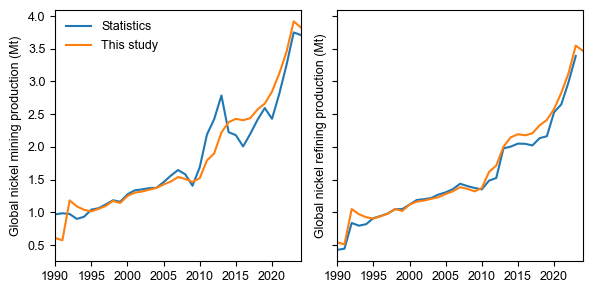

In [33]:
def plot_variance(df):
    
    year_min=1990
    year_max=2024
    df = df.loc[year_min:year_max,]
    df = df/1000  ## from kt to Mt
    
    fig, axes = plt.subplots(1,2, figsize=(6, 3), sharex=True, sharey=True)
    
    axes[0].plot(df.index, df.Mining, label='Statistics')
    axes[0].plot(df.index, df.P1_P2, label='This study')
    
    axes[1].plot(df.index, df.Refining, label='Statistics')
    axes[1].plot(df.index, df.P2_P4, label='This study')

    axes[0].set_ylabel('Global nickel mining production (Mt)')
    axes[1].set_ylabel('Global nickel refining production (Mt)')
    
    axes[0].legend(frameon=False)
    
    for ax in axes:
        ax.set_xlim(year_min,year_max)
        ax.set_xlabel('')
        ax.set_xticks(np.arange(year_min,year_max+1,5))
        
    plt.tight_layout()
    
    plt.savefig(file_path + 'Sector_Cu_Ni_Co/His_Nickel_Variance.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()

    
plot_variance(df_world_flow)

In [34]:
end_time = time.time()
execution_time = end_time - start_time
hours = execution_time // 3600 
minutes = (execution_time % 3600) // 60 
seconds = execution_time % 60 

print(f"代码运行时间: {int(hours)}小时 {int(minutes)}分钟 {int(seconds)}秒")

代码运行时间: 0小时 0分钟 39秒
